# CS610 Applied Machine Learning Assignment 2

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os

In [2]:
import warnings
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

from sklearn.metrics import (
    f1_score,
    hamming_loss,
    average_precision_score,
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)

2026-03-05 15:07:15.219858: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772723235.434223      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772723235.495275      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772723236.011090      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772723236.011148      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772723236.011151      24 computation_placer.cc:177] computation placer alr

In [3]:
BASE_PATH = '/kaggle/input/datasets/jessicali9530/celeba-dataset'
IMG_DIR = os.path.join(BASE_PATH, 'img_align_celeba', 'img_align_celeba')

IMG_SIZE = [64, 64]          # resize all images to 64x64
BATCH_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE
NUM_ATTRS = 40

In [4]:
attrs_df = pd.read_csv(os.path.join(BASE_PATH, 'list_attr_celeba.csv'))
partition_df = pd.read_csv(os.path.join(BASE_PATH, 'list_eval_partition.csv'))

print("Attributes shape:", attrs_df.shape)
print("Partition shape: ", partition_df.shape)

Attributes shape: (202599, 41)
Partition shape:  (202599, 2)


# Data Pre-Processing

In [5]:
# Convert the class value '-1' to '0' for future convenience
attr_columns = list(attrs_df.columns[1:])
attrs_df[attr_columns] = attrs_df[attr_columns].replace(-1, 0)

print("\nAttribute labels (first 10 rows)")
print(attrs_df.iloc[:10, :])

print("\nPartition labels (first 10 rows)")
print(partition_df.head(10))


Attribute labels (first 10 rows)
     image_id  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
0  000001.jpg                 0                1           1                0   
1  000002.jpg                 0                0           0                1   
2  000003.jpg                 0                0           0                0   
3  000004.jpg                 0                0           1                0   
4  000005.jpg                 0                1           1                0   
5  000006.jpg                 0                1           1                0   
6  000007.jpg                 1                0           1                1   
7  000008.jpg                 1                1           0                1   
8  000009.jpg                 0                1           1                0   
9  000010.jpg                 0                0           1                0   

   Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  Blond_Hair  Blurry  \
0   

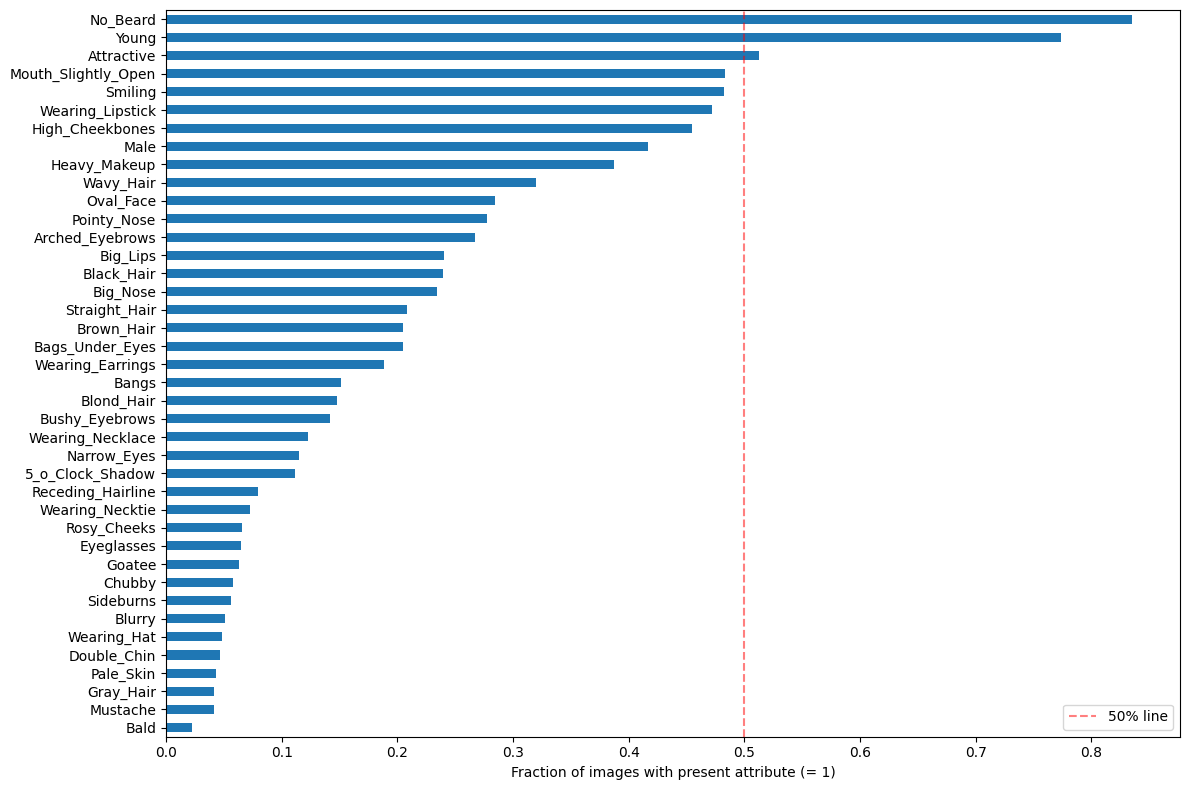

Most imbalanced attributes:
Bald           0.022443
Mustache       0.041545
Gray_Hair      0.041950
Pale_Skin      0.042947
Double_Chin    0.046688
Wearing_Hat    0.048460
Blurry         0.050899
Sideburns      0.056511
Chubby         0.057567
Goatee         0.062764

Most common attributes:
Smiling                0.482080
Mouth_Slightly_Open    0.483428
Attractive             0.512505
Young                  0.773617
No_Beard               0.834940


In [6]:
positive_rates = attrs_df[attr_columns].mean().sort_values()

# Check class imbalance on attributes
fig, ax = plt.subplots(figsize=(12, 8))
positive_rates.plot(kind='barh', ax=ax)
ax.set_xlabel('Fraction of images with present attribute (= 1)')
ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='50% line')
ax.legend()
plt.tight_layout()
plt.show()

print("Most imbalanced attributes:")
print(positive_rates.head(10).to_string())
print("\nMost common attributes:")
print(positive_rates.tail(5).to_string())

### Initial Inspection
Most traits are imbalanced. Attributes like "Bald", "Mustache" rarely exist while attributes like "No Beard" and "Young" are very common. 

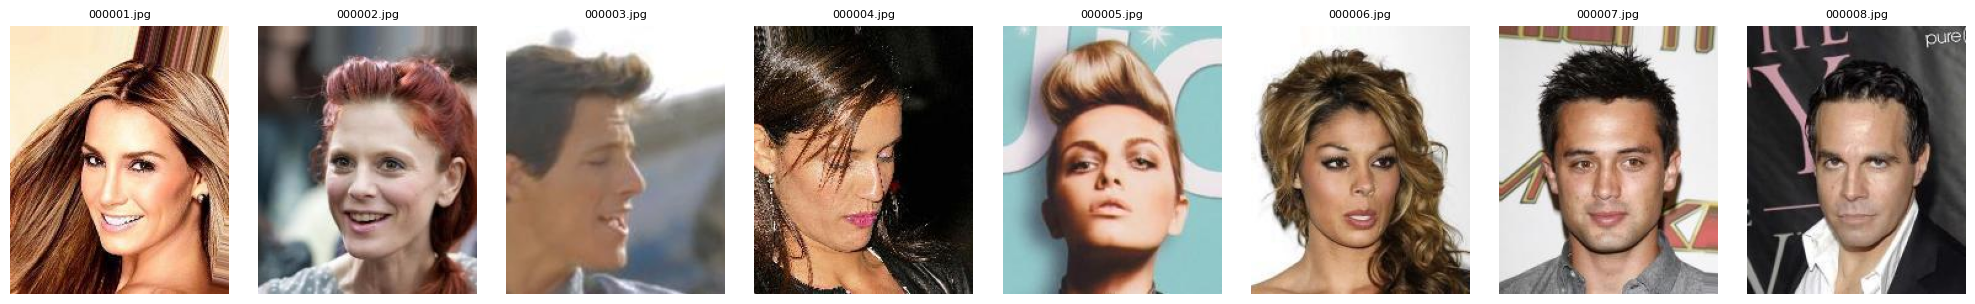

In [7]:
# Check samples from the dataset
sample_ids = attrs_df['image_id'].values[:8]
fig, axes = plt.subplots(1, 8, figsize=(20, 3))
for ax, img_id in zip(axes, sample_ids):
    img_path = os.path.join(IMG_DIR, img_id)
    img = plt.imread(img_path)
    ax.imshow(img)
    ax.set_title(img_id, fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [8]:
# Merge attributes with partition info
df = attrs_df.merge(partition_df, on='image_id')

# Split by partition
train_df = df[df['partition'] == 0].reset_index(drop=True)
val_df = df[df['partition'] == 1].reset_index(drop=True)
test_df = df[df['partition'] == 2].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))
print("Total:", len(train_df) + len(val_df) + len(test_df))

Train: 162770
Val: 19867
Test: 19962
Total: 202599


In [9]:
def load_and_preprocess(image_path, labels):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    # Normalize [0, 255] to [0, 1.0]
    img = img / 255.0
    return img, labels

In [10]:
def build_dataset(dataframe, cache_path=None, shuffle=False):
    paths  = dataframe['image_id'].apply(lambda x: os.path.join(IMG_DIR, x)).values
    labels = dataframe[attr_columns].values.astype(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)

    if cache_path:
        ds = ds.cache(cache_path)
    else:
        ds = ds.cache()

    if shuffle:
        ds = ds.shuffle(buffer_size=10_000)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

In [11]:
train_ds = build_dataset(train_df, cache_path='/kaggle/working/cache_train', shuffle=True)
val_ds   = build_dataset(val_df)
test_ds  = build_dataset(test_df)

I0000 00:00:1772723267.129480      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772723267.135595      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


(128, 64, 64, 3)
(128, 40)
0.0 1.0
[np.float32(0.0), np.float32(1.0)]


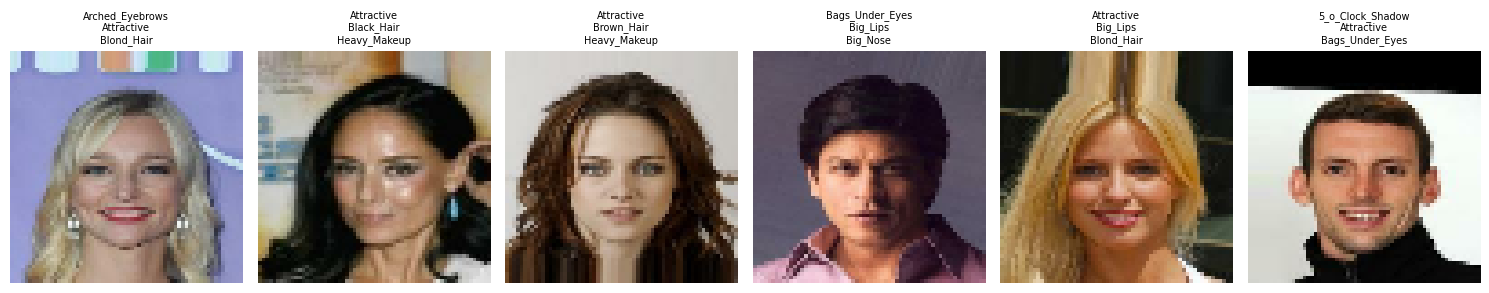

In [12]:
# Check the processed images and format
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)
    print(images.numpy().min(), images.numpy().max())
    print(sorted(np.unique(labels.numpy())))

    fig, axes = plt.subplots(1, 6, figsize=(15, 3))
    for i, ax in enumerate(axes):
        ax.imshow(images[i].numpy())
        pos_attrs = [attr_columns[j] for j in range(NUM_ATTRS) if labels[i][j] == 1]
        ax.set_title('\n'.join(pos_attrs[:3]),fontsize=7)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Question 1: Implementing a Baseline MLP for CelebA Attribute Prediction

### We can use a Metric subclass from Keras to define the Hamming Loss metric

In [13]:
class HammingLossMetric(tf.keras.metrics.Metric):
    def __init__(self, threshold=0.5, name='hamming_loss', **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold
        self.total_incorrect = self.add_weight(name='total_incorrect', initializer='zeros')
        self.total_elements = self.add_weight(name='total_elements', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_bin = tf.cast(y_pred > self.threshold, y_true.dtype)
        incorrect  = tf.reduce_sum(
            tf.cast(tf.not_equal(y_true, y_pred_bin), tf.float32)
        )
        elements = tf.cast(tf.size(y_true), tf.float32)
        self.total_incorrect.assign_add(incorrect)
        self.total_elements.assign_add(elements)

    def result(self):
        return self.total_incorrect / self.total_elements

    def reset_state(self):
        self.total_incorrect.assign(0.0)
        self.total_elements.assign(0.0)

In [14]:
def full_evaluate(model, dataset, threshold=0.5, dataset_name="Test"):
    y_true_all = []
    y_prob_all = []

    for images, labels in dataset:
        probs = model(images, training=False)
        y_true_all.append(labels.numpy())
        y_prob_all.append(probs.numpy())

    y_true = np.concatenate(y_true_all, axis=0)
    y_prob = np.concatenate(y_prob_all, axis=0)
    y_pred = (y_prob > threshold).astype(np.float32)

    metrics = {
        'binary_accuracy': np.mean(y_true == y_pred),
        'hamming_loss': hamming_loss(y_true, y_pred),
        'micro_f1': f1_score(y_true, y_pred, average='micro', zero_division=0),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'micro_mAP': average_precision_score(y_true, y_prob, average='micro'),
        'macro_mAP': average_precision_score(y_true, y_prob, average='macro'),
    }

    print()
    print(dataset_name, "Metrics (threshold =", threshold, ")")
    for k, v in metrics.items():
        print(k + ":", round(v, 4))

    return metrics, y_true, y_prob

In [15]:
def plot_history(history, title=""):
    metrics_to_plot = [
        ('loss', 'Loss'),
        ('binary_accuracy', 'Binary Accuracy'),
        ('hamming_loss', 'Hamming Loss'),
    ]

    n = len(metrics_to_plot)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))

    for ax, (metric_key, label) in zip(axes, metrics_to_plot):
        train_vals = history.history[metric_key]
        val_vals = history.history['val_' + metric_key]
        epochs = range(1, len(train_vals) + 1)

        ax.plot(epochs, train_vals, 'o-', label='Train', markersize=3)
        ax.plot(epochs, val_vals, 's-', label='Val', markersize=3)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(label)
        ax.set_title(title + ' -- ' + label if title else label)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [16]:
def build_baseline_mlp():
    model = models.Sequential([
        layers.Flatten(input_shape=(*IMG_SIZE, 3)),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(40, activation='sigmoid'),
    ], name='baseline_mlp')
    return model

q1_model = build_baseline_mlp()
q1_model.summary()

Model: "baseline_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 40)             │        10,280 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,433,576 (24.54 MB)

 Trainable params: 6,433,576 (24.54 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
q1_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='binary_accuracy'),
        HammingLossMetric(name='hamming_loss'),
    ]
)

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1,
)

q1_history = q1_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/100


I0000 00:00:1772723291.262188      71 service.cc:152] XLA service 0x7f22cc004cd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772723291.262229      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772723291.262235      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772723291.597834      71 cuda_dnn.cc:529] Loaded cuDNN version 91002


   1/1272 ━━━━━━━━━━━━━━━━━━━━ 2:12:30 6s/step - binary_accuracy: 0.5705 - hamming_loss: 0.4295 - loss: 0.6902

I0000 00:00:1772723292.660548      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1272/1272 ━━━━━━━━━━━━━━━━━━━━ 330s 255ms/step - binary_accuracy: 0.8423 - hamming_loss: 0.1577 - loss: 0.3766 - val_binary_accuracy: 0.8726 - val_hamming_loss: 0.1274 - val_loss: 0.2958
Epoch 2/100
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - binary_accuracy: 0.8730 - hamming_loss: 0.1270 - loss: 0.2922 - val_binary_accuracy: 0.8753 - val_hamming_loss: 0.1247 - val_loss: 0.2874
Epoch 3/100
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - binary_accuracy: 0.8776 - hamming_loss: 0.1224 - loss: 0.2809 - val_binary_accuracy: 0.8813 - val_hamming_loss: 0.1187 - val_loss: 0.2741
Epoch 4/100
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - binary_accuracy: 0.8801 - hamming_loss: 0.1199 - loss: 0.2743 - val_binary_accuracy: 0.8843 - val_hamming_loss: 0.1157 - val_loss: 0.2664
Epoch 5/100
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - binary_accuracy: 0.8820 - hamming_loss: 0.1180 - loss: 0.2698 - val_binary_accuracy: 0.8837 - val_hamming_loss: 0.1163 - val_loss: 0.2676
Epoch 6/100
1272/1272 ━━━━━━━

## Baseline Model Evaluation & Discussion

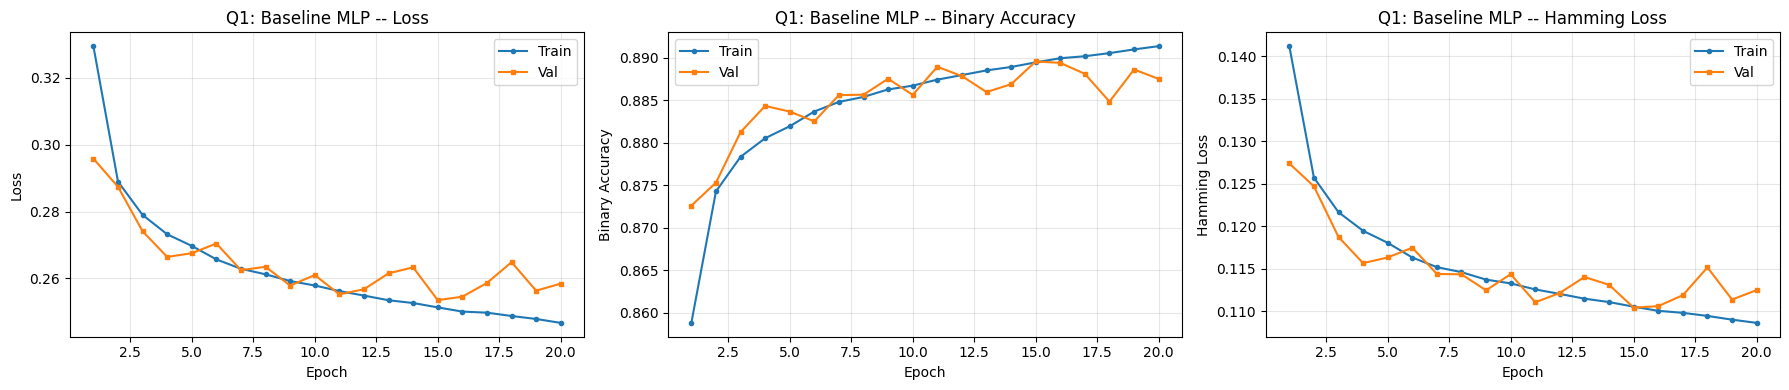

In [18]:
plot_history(q1_history, title="Q1: Baseline MLP")

In [19]:
# Evaluate on the Test set
q1_metrics, q1_y_true, q1_y_prob = full_evaluate(
    q1_model, test_ds
)


Test Metrics (threshold = 0.5 )
binary_accuracy: 0.8842
hamming_loss: 0.1158
micro_f1: 0.7152
macro_f1: 0.5307
micro_mAP: 0.8416
macro_mAP: 0.6496


### Discussion
**Based on the training and validation trends, the model shows clear signs of overfitting.**

**During the first half of training, both metrics improve together. However, at around epoch 15, the validation loss starts to flatten and becomes jittery, while the training loss continues to decrease steadily. A widening gap also forms between the training accuracy and the validation accuracy.**

**Since most attributes are imbalanced, a high binary accuracy and a low hamming loss are not significant indicators of the model's performance, because they are easily inflated by the high accuracy obtained through predicting 0 on the rare attributes.**

**The micro-F1 looks solid. Common attributes like "No_Beard" and "Young" can heavily influence the model's performance metrics. As for the macro-F1, we ignore the frequency of each attribute, so common attributes and rare attributes are treated equally. The low macro-F1 of 0.5556 indicates our model did not perform well on predicting rare, imbalanced attributes such as "Bald" or "Mustache."**

**The same rationale applies to macro-mAP as the model struggles to handle the less common attributes, which is why we observe a low macro-mAP of 0.6571, while also seeing a good micro-mAP of 0.8457 as it is calculated based on all attributes together instead of each specific attribute separately. Hence, the good performance on the common attributes overshadows the model's weak capability to rank the less common ones.**

**Overall, our baseline model falls into memorizing the pixel patterns of the training set, eventually leading to overfitting.**

In [20]:
# Save model
q1_model.save('q1_baseline_mlp.keras')
print("Model saved to q1_baseline_mlp.keras")

# Save training history for plotting curves in the future
import json
with open('q1_history.json', 'w') as f:
    json.dump(q1_history.history, f, indent=2)

# # We can load the model for future use without retraining
# loaded = tf.keras.models.load_model(
#     'q1_baseline_mlp.keras',
#     custom_objects={'HammingLossMetric': HammingLossMetric}
# )
# print("Loaded model has", loaded.count_params(), "parameters")

Model saved to q1_baseline_mlp.keras


### We can load the saved json file for plotting without training the model again.

In [21]:
# import json

# with open('q1_history.json') as f:
#     history_dict = json.load(f)

# class _History:
#     pass
# h = _History()
# h.history = history_dict
# plot_history(h, title="Q1 Baseline MLP")

# Question 2: Improving the MLP for Multi-Label Attribute Prediction

## Train and Evaluate Different Architectural Setups

In [22]:
# Build the shallow MLP
def build_shallow_mlp():
    model = models.Sequential([
        layers.Flatten(input_shape=(*IMG_SIZE, 3)),
        layers.Dense(512, activation='relu'),
        layers.Dense(40, activation='sigmoid'),
    ], name='shallow_mlp')
    return model

In [23]:
# Build the deep MLP
def build_deep_mlp():
    model = models.Sequential([
        layers.Flatten(input_shape=(*IMG_SIZE, 3)),
        layers.Dense(1024, activation='relu'),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(40, activation='sigmoid'),
    ], name='deep_mlp')
    return model

In [24]:
# Build the wide MLP
def build_wide_mlp():
    model = models.Sequential([
        layers.Flatten(input_shape=(*IMG_SIZE, 3)),
        layers.Dense(1024, activation='relu'),
        layers.Dense(512, activation='relu'),
        layers.Dense(40, activation='sigmoid'),
    ], name='wide_mlp')
    return model

In [25]:
# Initialize dictionaries for following training
arch_variants = {
    'shallow': build_shallow_mlp,
    'deep': build_deep_mlp,
    'wide': build_wide_mlp,
}

arch_results = {}
arch_histories = {}

In [26]:
for name, build_fn in arch_variants.items():
    print("Training:", name)
    model = build_fn()
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.BinaryAccuracy(name='binary_accuracy'), HammingLossMetric(name='hamming_loss')]
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
        verbose=1,
    )

    metrics, _, _ = full_evaluate(model, test_ds, dataset_name=name)
    arch_results[name] = metrics
    arch_histories[name] = history.history
    print()

Training: shallow
Epoch 1/100
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - binary_accuracy: 0.8416 - hamming_loss: 0.1584 - loss: 0.3977 - val_binary_accuracy: 0.8725 - val_hamming_loss: 0.1275 - val_loss: 0.2964
Epoch 2/100
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - binary_accuracy: 0.8712 - hamming_loss: 0.1288 - loss: 0.2976 - val_binary_accuracy: 0.8743 - val_hamming_loss: 0.1257 - val_loss: 0.2913
Epoch 3/100
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - binary_accuracy: 0.8753 - hamming_loss: 0.1247 - loss: 0.2873 - val_binary_accuracy: 0.8796 - val_hamming_loss: 0.1204 - val_loss: 0.2791
Epoch 4/100
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - binary_accuracy: 0.8781 - hamming_loss: 0.1219 - loss: 0.2803 - val_binary_accuracy: 0.8812 - val_hamming_loss: 0.1188 - val_loss: 0.2743
Epoch 5/100
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - binary_accuracy: 0.8792 - hamming_loss: 0.1208 - loss: 0.2775 - val_binary_accuracy: 0.8807 - val_hamming_loss: 0.1193 - val_loss: 0.2771
Ep

### Performance Table
| **Model**                   | **Binary Accuracy** | **Hamming Loss** | **Micro-F1** | **Macro-F1** | **Micro-mAP** | **Macro-mAP** |
| --------------------------- | -------------- | ---------------- | ------------ | ------------ | ------------- | ------------- |
| **Baseline (512→256)**      | 0.8859         | 0.1141           | 0.7280       | 0.5556       | 0.8457        | 0.6571        |
| **Shallow (512)**           | 0.8837         | 0.1163           | 0.7196       | 0.5419       | 0.8390        | 0.6452        |
| **Deep (1024→512→256→128)** | 0.8855         | 0.1145           | 0.7273       | 0.5518       | 0.8442        | 0.6524        |
| **Wide (1024→512)**         | 0.8843         | 0.1157           | 0.7285       | 0.5569       | 0.8422        | 0.6513        |


**Surprisingly, altering only the depth and width of the Multi-Layer Perceptron generally degraded overall performance compared to the baseline model. Only the wide configuration provided minimal improvement on Macro-F1.**

**We speculate that without regularization, adding more parameters via depth or width does not turn into better generalization other than getting wasted on overfitting.**

## Train and Evaluate Shallow/Deep/Wide with LR Scheduling Only

**We want to isolate the effect of LR scheduling on each architecture to have a clearer observation of how Learning Rate scheduling influence the model performance.**

In [27]:
# Set ExponentialDecay by 5% each epoch and initialize dictionaries for results
lr_schedule = optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=1272,
    decay_rate=0.95,
)

lr_results = {}
lr_histories = {}

In [28]:
for name, build_fn in arch_variants.items():
    print("Training with LR schedule:", name)
    model = build_fn()
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr_schedule),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.BinaryAccuracy(name='binary_accuracy'), HammingLossMetric(name='hamming_loss')]
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
        verbose=1,
    )

    metrics, _, _ = full_evaluate(model, test_ds, dataset_name=name + " + LR Scheduling")
    lr_results[name + ' + LR Scheduling'] = metrics
    lr_histories[name + ' + LR Scheduling'] = history.history
    print()

Training with LR schedule: shallow
Epoch 1/100
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - binary_accuracy: 0.8426 - hamming_loss: 0.1574 - loss: 0.3929 - val_binary_accuracy: 0.8711 - val_hamming_loss: 0.1289 - val_loss: 0.3010
Epoch 2/100
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - binary_accuracy: 0.8710 - hamming_loss: 0.1290 - loss: 0.2978 - val_binary_accuracy: 0.8765 - val_hamming_loss: 0.1235 - val_loss: 0.2867
Epoch 3/100
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - binary_accuracy: 0.8760 - hamming_loss: 0.1240 - loss: 0.2861 - val_binary_accuracy: 0.8804 - val_hamming_loss: 0.1196 - val_loss: 0.2787
Epoch 4/100
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - binary_accuracy: 0.8783 - hamming_loss: 0.1217 - loss: 0.2801 - val_binary_accuracy: 0.8816 - val_hamming_loss: 0.1184 - val_loss: 0.2746
Epoch 5/100
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - binary_accuracy: 0.8802 - hamming_loss: 0.1198 - loss: 0.2753 - val_binary_accuracy: 0.8822 - val_hamming_loss: 0.1178 - val_

### Updated Performance Table

|**Model**|**Binary Accuracy**|**Hamming Loss**|**Micro-F1**|**Macro-F1**|**Micro-mAP**|**Macro-mAP**|
|---|---|---|---|---|---|---|
|**Baseline (512→256)**|0.8859|0.1141|0.7280|0.5556|0.8457|0.6571|
|**Shallow (512)**|0.8837|0.1163|0.7196|0.5419|0.8390|0.6452|
|**Shallow + LR**|0.8856|0.1144|0.7285|0.5611|0.8441|0.6530|
|**Deep (1024→512→256→128)**|0.8855|0.1145|0.7273|0.5518|0.8442|0.6524|
|**Deep + LR**|0.8866|0.1134|0.7293|0.5598|0.8474|0.6612|
|**Wide (1024→512)**|0.8843|0.1157|0.7285|0.5569|0.8422|0.6513|
|**Wide + LR**|**0.8879**|**0.1121**|**0.7324**|**0.5736**|**0.8506**|**0.6678**|

**Using Exponential Decay learning rate scheduling returned consistent improvements over all different configs, especially the Macro-F1 scores. Among all different configs, the Wide + LR model achieved the best acuracy of 0.8879 and best Macro-F1 of 0.5736. The plain static learning rate of 0.001 proved to be too aggressive for later stages of training.**


## Train and Evaluate Shallow/Deep/Wide with LR Scheduling + Regularization

**Now we add all three regularization techniques on top of LR scheduling. We can now observe how regularization techniques can help with the model performance and overfitting issues.**